## 1) descripción del problema

Se requiere desarrollar un sistema que permita modelar una red de lugares utilizando un grafo no dirigido, donde:

Cada nodo representa un lugar.
Cada arista representa una conexión entre lugares.

El sistema debe permitir:

Crear la red de nodos.
Establecer conexiones entre ellos.
Representar el grafo como:
Lista de adyacencia
Matriz de adyacencia
Recorrer el grafo mediante:
BFS (recorrido por niveles)
DFS (recorrido en profundidad)
Agregar nuevos nodos dinámicamente.

## 2) Requerimientos
Lista requerimientos **funcionales** y **no funcionales**.

R1. Crear la red de lugares ingresados por el usuario.

R2. Validar que los datos ingresados sean correctos.

R3. Establecer conexiones entre los lugares.

R4. Mostrar la lista de adyacencia del grafo.

R5. Generar y mostrar la matriz de adyacencia.
R6. Recorrer el grafo usando BFS.

R7. Recorrer el grafo usando DFS.

R8. Agregar un nuevo lugar y conectarlo a la red.

R9. Mostrar la red actualizada después de modificaciones.

R10. Permitir la interacción mediante un menú.




## 3) Historias de usuario
 H1.
Como usuario, quiero crear una red de lugares para representar conexiones entre ellos.

H2.
Como usuario, quiero ingresar datos válidos para evitar errores en el sistema.

H3.
Como usuario, quiero conectar lugares para representar relaciones entre ellos.

H4.
Como usuario, quiero ver la lista de adyacencia para entender las conexiones.

H5.
Como usuario, quiero ver la matriz de adyacencia para analizar el grafo.

H6.
Como usuario, quiero recorrer la red usando BFS para analizar conexiones por niveles.

H7.
Como usuario, quiero recorrer la red usando DFS para explorar caminos completos.

H8.
Como usuario, quiero agregar nuevos lugares para actualizar la red.

H9.
Como usuario, quiero ver la red actualizada después de cambios.

H10.
Como usuario, quiero usar un menú para interactuar fácilmente con el sistema.

## 4) Diagramas de flujo
Incluye el diagrama que muestre el proceso general con memoización

Adjunta imagen y descríbelo claramente.

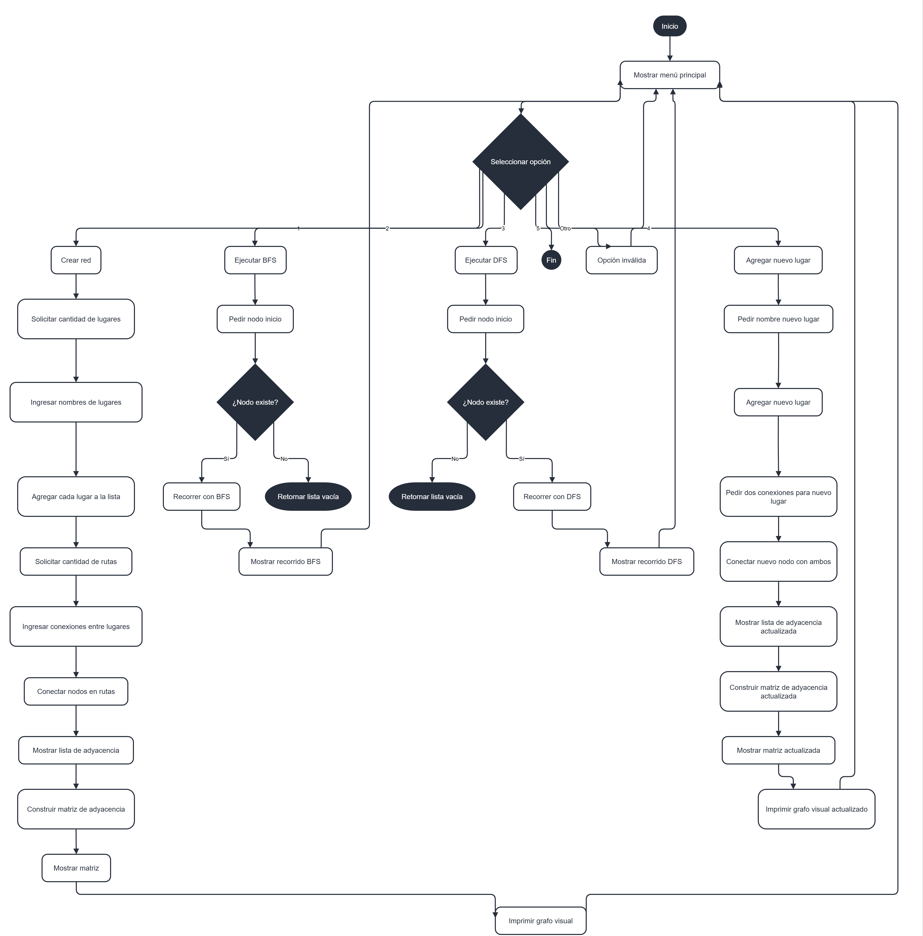




## 5) Diagramas de secuencia
Incluye un diagrama de secuencia.

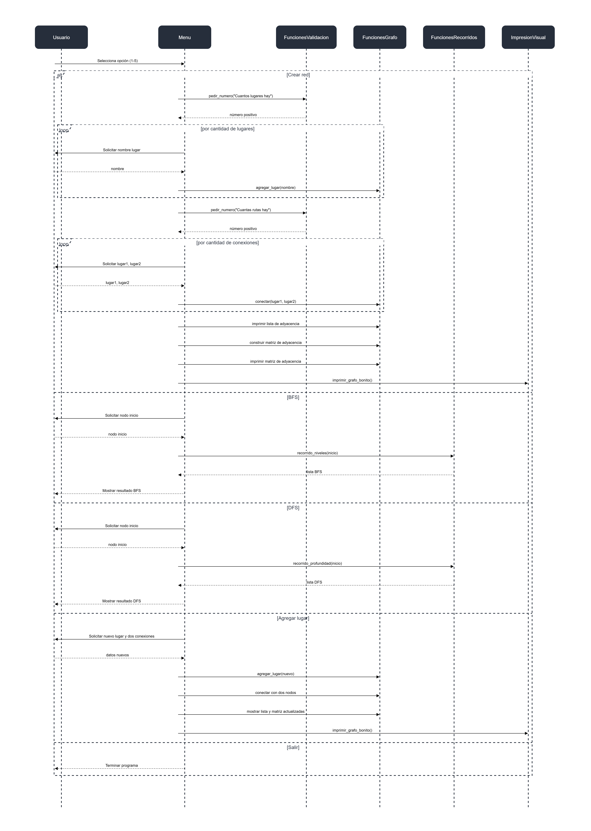

Adjunta imagen y descríbelo claramente.

## 6) Diagramas de casos de uso
Incluye diagrama de casos de uso.

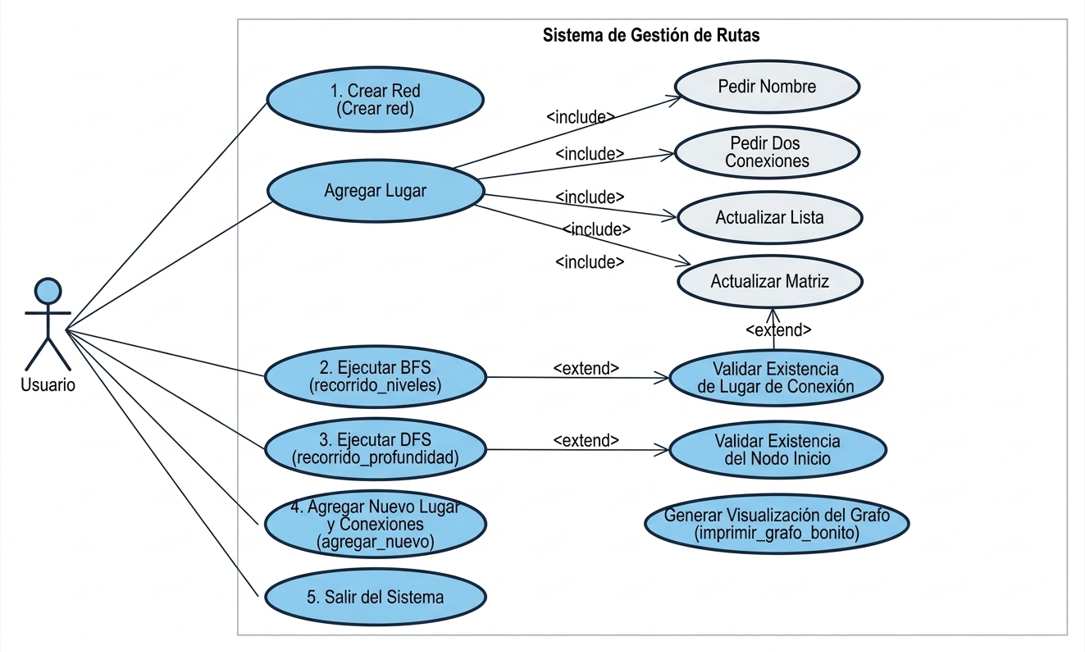

Adjunta imagen y descríbelo claramente.


## 7) Análisis de complejidad
Incluye:
- Función T[n]
- Graficas Mejor y peor caso

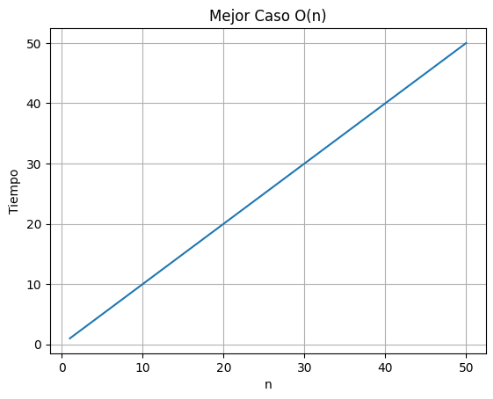

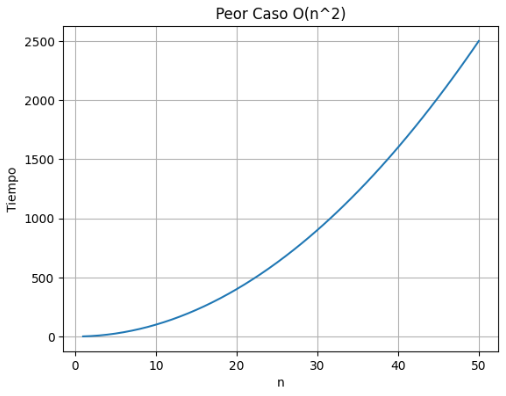

Mejor caso: El algoritmo recorre cada nodo una sola vez, por lo tanto el crecimiento es lineal.

Peor caso: Debido al ordenamiento de vecinos (tipo burbuja), el tiempo aumenta cuadráticamente.

## 8) Tests
Define un conjunto de pruebas

Test 1: Búsqueda de un lugar existente

Función: buscar()

Entrada: lugares = ["A", "B", "C"], buscar("B")

Proceso: Se recorre la lista hasta encontrar el elemento.

Salida esperada: 1

Resultado: Correcto


Test 2: Búsqueda de un lugar inexistente

Función: buscar()

Entrada: lugares = ["A", "B", "C"], buscar("D")

Proceso: Se recorre toda la lista sin encontrar el elemento.

Salida esperada: -1

Resultado: Correcto


Test 3: Agregar un lugar

Función: agregar_lugar()

Entrada: agregar_lugar("A")

Proceso: Se añade el lugar a la lista y se crea una lista vacía en rutas.

Salida esperada:

lugares = ["A"]

rutas = [[]]

Resultado: Correcto


Test 4: Conectar dos lugares

Función: conectar()

Entrada: conectar("A", "B")

Proceso: Se buscan las posiciones y se agregan mutuamente.

Salida esperada:

A → B
B → A

Resultado: Correcto




Test 5: Recorrido BFS (por niveles)

Función: recorrido_niveles()

Entrada:

Lugares: A, B, C

Conexiones: A-B, A-C

Inicio: A

Proceso:

Se usa una cola para recorrer primero los vecinos más cercanos.

Salida esperada:

["A", "B", "C"]

Resultado: Correcto



Test 6: Recorrido DFS (profundidad)

Función: recorrido_profundidad()

Entrada:

Lugares: A, B, C

Conexiones: A-B, A-C

Inicio: A

Proceso:

Se recorre primero un camino completo antes de regresar.

Salida esperada:

["A", "B", "C"]

Resultado: Correcto


Test 7: Nodo inexistente en recorrido

Función: BFS y DFS

Entrada: Inicio = "X" (no existe)

Proceso: No se encuentra el nodo inicial

Salida esperada: []

Resultado: Correcto



Test 8: Grafo sin conexiones

Función: recorrido_niveles()

Entrada:

Lugares: ["A"]

Sin conexiones

Salida esperada: ["A"]

Resultado: Correcto

## 9) Código funcional
Incluye tu implementación completa.

**Recomendaciones (ajústalas a tu lenguaje):**
- Separar validación de entrada del cálculo.
- Implementar memoización (diccionario/array).
- Documentar brevemente con comentarios.
- Incluir una función principal que permita ejecutar.

⚠️ No pegues código incompleto; debe ser ejecutable.

# Escribe tu código aquí.
# Debe incluir: validación, función memoizada, y ejecución.

# lugares: guarda los nodos
lugares = []
# rutas: guarda con quien se conecta
rutas = []

# saber donde esta el nodo dentro de la lista
def buscar(nombre):
    for i in range(len(lugares)):
        if lugares[i] == nombre:
            return i
    return -1

# crea lista vacia entre rutas
def agregar_lugar(nombre):
    lugares.append(nombre)
    rutas.append([])

# une dos nodos
def conectar(a, b):
    i = buscar(a)
    j = buscar(b)
    if i != -1 and j != -1:
        if lugares[j] not in rutas[i]:
            rutas[i].append(lugares[j])
        if lugares[i] not in rutas[j]:
            rutas[j].append(lugares[i])

def pedir_numero(mensaje):
    while True:
        num = int(input(mensaje))
        if num > 0:
            return num
        else:
            print("Ingrese un numero positivo")

# 🔥 NUEVA FUNCIÓN BONITA
def imprimir_grafo_bonito():
    print("\nGrafo (visual):")
    visitados = [False] * len(lugares)

    def dfs_visual(i, indent="", last=True):
        print(indent, "└── " if last else "├── ", lugares[i], sep="")
        indent += "    " if last else "│   "
        visitados[i] = True

        vecinos = rutas[i][:]
        vecinos.sort()

        hijos = []
        for v in vecinos:
            j = buscar(v)
            if not visitados[j]:
                hijos.append(j)

        for k in range(len(hijos)):
            dfs_visual(hijos[k], indent, k == len(hijos) - 1)

    for i in range(len(lugares)):
        if not visitados[i]:
            dfs_visual(i)

# crear red
def crear_red():
    global lugares, rutas
    lugares = []
    rutas = []

    cantidad = pedir_numero("Cuantos lugares hay: ")
    for i in range(cantidad):
        nombre = input("Nombre del lugar: ")
        agregar_lugar(nombre)

    conexiones = pedir_numero("Cuantas rutas hay: ")
    for i in range(conexiones):
        a = input("Lugar 1: ")
        b = input("Lugar 2: ")
        conectar(a, b)

    print("Lista de adyacencia:")
    for i in range(len(lugares)):
        print(lugares[i], "->", rutas[i])

    tamaño = len(lugares)
    matriz = []

    for i in range(tamaño):
        fila = []
        for j in range(tamaño):
            fila.append(0)
        matriz.append(fila)

    for i in range(tamaño):
        for vecino in rutas[i]:
            j = buscar(vecino)
            matriz[i][j] = 1

    print("Matriz:")
    print("  ", end="")
    for n in lugares:
        print(n, end=" ")
    print()

    for i in range(tamaño):
        print(lugares[i], end=" ")
        for j in range(tamaño):
            print(matriz[i][j], end=" ")
        print()

    # 🔥 imprimir bonito
    imprimir_grafo_bonito()

# BFS
def recorrido_niveles(inicio):
    visitados = [False] * len(lugares)
    cola = []
    orden = []

    i = buscar(inicio)
    if i == -1:
        return orden

    cola.append(i)
    visitados[i] = True

    while len(cola) > 0:
        actual = cola.pop(0)
        orden.append(lugares[actual])

        vecinos = rutas[actual][:]
        vecinos.sort()

        for v in vecinos:
            j = buscar(v)
            if not visitados[j]:
                cola.append(j)
                visitados[j] = True

    return orden

# DFS
def recorrido_profundidad(inicio):
    visitados = [False] * len(lugares)
    orden = []

    def recorrer(i):
        visitados[i] = True
        orden.append(lugares[i])

        vecinos = rutas[i][:]
        vecinos.sort()

        for v in vecinos:
            j = buscar(v)
            if not visitados[j]:
                recorrer(j)

    i = buscar(inicio)
    if i != -1:
        recorrer(i)

    return orden

# agregar nodo nuevo
def agregar_nuevo():
    nuevo = input("Nuevo lugar: ")
    agregar_lugar(nuevo)
    a = input("Conectar con: ")
    b = input("Conectar con: ")
    conectar(nuevo, a)
    conectar(nuevo, b)

# menu
def menu():
    while True:
        print("\n--- MENU ---")
        print("1. Crear red")
        print("2. BFS")
        print("3. DFS")
        print("4. Agregar lugar")
        print("5. Salir")

        op = input("Opcion: ")

        if op == "1":
            crear_red()

        elif op == "2":
            inicio = input("Inicio: ")
            print("BFS:", recorrido_niveles(inicio))

        elif op == "3":
            inicio = input("Inicio: ")
            print("DFS:", recorrido_profundidad(inicio))

        elif op == "4":
            agregar_nuevo()

            print("Nueva red:")
            print("Lista de adyacencia:")
            for i in range(len(lugares)):
                print(lugares[i], "->", rutas[i])

            tamaño = len(lugares)
            matriz = []

            for i in range(tamaño):
                fila = []
                for j in range(tamaño):
                    fila.append(0)
                matriz.append(fila)

            for i in range(tamaño):
                for vecino in rutas[i]:
                    j = buscar(vecino)
                    matriz[i][j] = 1

            print("Matriz:")
            print("  ", end="")
            for n in lugares:
                print(n, end=" ")
            print()

            for i in range(tamaño):
                print(lugares[i], end=" ")
                for j in range(tamaño):
                    print(matriz[i][j], end=" ")
                print()

            # 🔥 imprimir bonito también aquí
            imprimir_grafo_bonito()

        elif op == "5":
            break
        else:
            print("Opcion invalida")

menu()


## 10) Tests aplicados (extras)
Muestra evidencia de pruebas ejecutadas:

Incluye al menos 2 pruebas adicionales (p.ej., n=20, n=30) y una prueba de validación (n negativo).

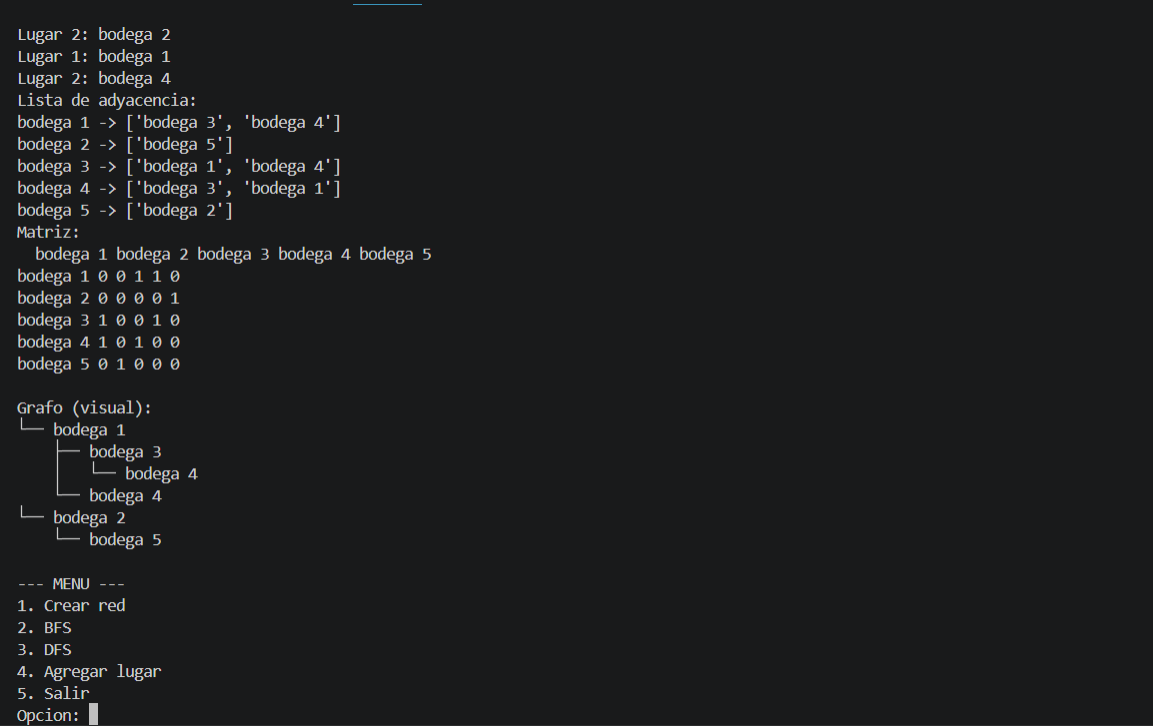


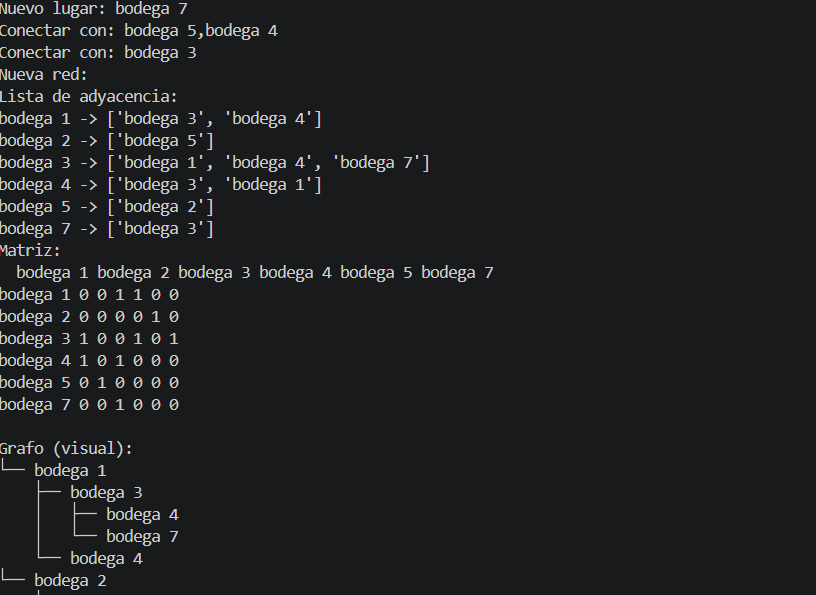


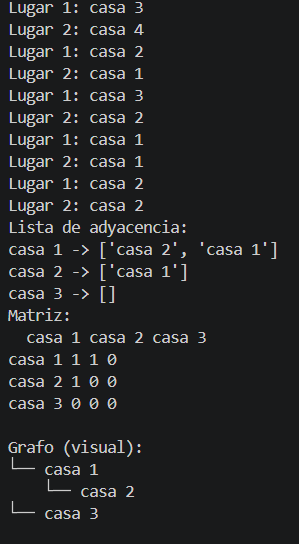


